# 03 - Data Cleaning, Preprocessing & Feature Engineering

This notebook runs the full preprocessing pipeline:
1. Missing value imputation (interpolation + KNN)
2. Outlier handling (winsorization)
3. AQI validation against CPCB formula
4. Feature engineering (temporal, lag, rolling, ratios)
5. Temporal train/val/test split
6. Save processed data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from config import (DATA_RAW, DATA_PROCESSED, POLLUTANT_COLS, AQI_POLLUTANTS,
                     FIGURES_DIR, RANDOM_STATE, TEST_SIZE, VAL_SIZE)
from src.data.preprocess import (load_city_day, missing_value_report,
                                  interpolate_within_groups, knn_impute,
                                  drop_sparse_rows, handle_outliers_iqr)
from src.data.aqi_calculator import compute_aqi_column, categorize_aqi
from src.data.feature_engineering import build_feature_matrix

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Ensure output directories exist
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load Raw Data

In [2]:
# Use the original 2015-2020 CPCB dataset (26 cities, verified correlations)
from config import RAW_CSV

df_raw = load_city_day(str(RAW_CSV))
print(f"Dataset: Air Quality Data in India (2015-2020, CPCB)")
print(f"Raw shape: {df_raw.shape}")
print(f"Cities: {df_raw['City'].nunique()} - {sorted(df_raw['City'].unique())}")
print(f"Date range: {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")

# Before: missing value report
print("\n--- Missing Values (BEFORE) ---")
report_before = missing_value_report(df_raw)
if len(report_before) > 0:
    print(report_before.to_string())
else:
    print("No missing values found!")

Dataset: Air Quality Data in India (2015-2020, CPCB)
Raw shape: (29531, 16)
Cities: 26 - ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']
Date range: 2015-01-01 to 2020-07-01

--- Missing Values (BEFORE) ---
            Missing  Pct_Missing
Xylene        18109        61.32
PM10          11140        37.72
NH3           10328        34.97
Toluene        8041        27.23
Benzene        5623        19.04
AQI            4681        15.85
AQI_Bucket     4681        15.85
PM2.5          4598        15.57
NOx            4185        14.17
O3             4022        13.62
SO2            3854        13.05
NO2            3585        12.14
NO             3582        12.13
CO             2059         6.97


## 2. Step 1: Linear Interpolation (within city groups)

In [3]:
pollutant_cols = [c for c in POLLUTANT_COLS if c in df_raw.columns]

df = interpolate_within_groups(df_raw, cols=pollutant_cols, limit=3)

# Compare before/after
before_missing = df_raw[pollutant_cols].isnull().sum()
after_interp = df[pollutant_cols].isnull().sum()
filled = before_missing - after_interp

comparison = pd.DataFrame({
    'Before': before_missing,
    'After_Interp': after_interp,
    'Filled': filled,
    'Fill_Pct': (filled / before_missing * 100).round(1)
})
print("Linear interpolation results:")
print(comparison[comparison['Filled'] > 0].sort_values('Fill_Pct', ascending=False).to_string())

Linear interpolation results:
         Before  After_Interp  Filled  Fill_Pct
CO         2059          1238     821      39.9
O3         4022          2989    1033      25.7
SO2        3854          2879     975      25.3
NO         3582          2734     848      23.7
NO2        3585          2739     846      23.6
PM2.5      4598          3869     729      15.9
Benzene    5623          4730     893      15.9
NOx        4185          3619     566      13.5
Toluene    8041          7278     763       9.5
NH3       10328          9574     754       7.3
PM10      11140         10368     772       6.9
Xylene    18109         17544     565       3.1


## 3. Step 2: KNN Imputation

In [4]:
before_knn = df[pollutant_cols].isnull().sum()

df = knn_impute(df, cols=pollutant_cols, n_neighbors=5)

after_knn = df[pollutant_cols].isnull().sum()
knn_filled = before_knn - after_knn

comparison_knn = pd.DataFrame({
    'Before_KNN': before_knn,
    'After_KNN': after_knn,
    'KNN_Filled': knn_filled
})
print("KNN imputation results:")
print(comparison_knn.to_string())
print(f"\nTotal remaining NaN in pollutants: {after_knn.sum()}")

KNN imputation results:
         Before_KNN  After_KNN  KNN_Filled
PM2.5          3869          0        3869
PM10          10368          0       10368
NO             2734          0        2734
NO2            2739          0        2739
NOx            3619          0        3619
NH3            9574          0        9574
CO             1238          0        1238
SO2            2879          0        2879
O3             2989          0        2989
Benzene        4730          0        4730
Toluene        7278          0        7278
Xylene        17544          0       17544

Total remaining NaN in pollutants: 0


## 4. Step 3: Drop Sparse Rows

In [5]:
before_drop = len(df)
df = drop_sparse_rows(df, cols=pollutant_cols, threshold=0.5)
print(f"Dropped {before_drop - len(df)} rows with >50% missing pollutants")
print(f"Remaining: {len(df)} rows")

Dropped 0 rows with >50% missing pollutants
Remaining: 29531 rows


## 5. Step 4: Outlier Handling (Winsorization)

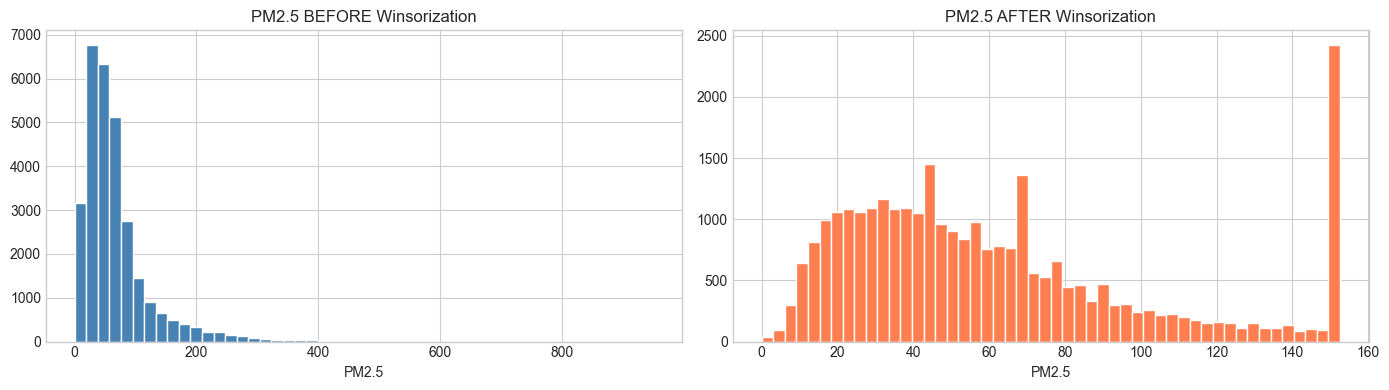

In [6]:
# Show before distribution for PM2.5
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['PM2.5'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5 BEFORE Winsorization')
axes[0].set_xlabel('PM2.5')

df = handle_outliers_iqr(df, cols=pollutant_cols)

axes[1].hist(df['PM2.5'].dropna(), bins=50, color='coral', edgecolor='white')
axes[1].set_title('PM2.5 AFTER Winsorization')
axes[1].set_xlabel('PM2.5')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_winsorization_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Step 5: AQI Validation

In [7]:
# Drop rows without original AQI
df = df.dropna(subset=['AQI']).reset_index(drop=True)
print(f"Rows with valid AQI: {len(df)}")

# Compute AQI from pollutant values and compare
df = compute_aqi_column(df)

# Compare original vs calculated
valid_mask = df['AQI_Calculated'].notna()
comparison_df = df[valid_mask][['City', 'Date', 'AQI', 'AQI_Calculated', 'Dominant_Pollutant']].copy()
comparison_df['Diff'] = abs(comparison_df['AQI'] - comparison_df['AQI_Calculated'])
comparison_df['Pct_Diff'] = (comparison_df['Diff'] / comparison_df['AQI'] * 100).round(1)

print(f"\nAQI Validation:")
print(f"  Rows with calculable AQI: {valid_mask.sum()} / {len(df)}")
print(f"  Mean absolute difference: {comparison_df['Diff'].mean():.1f}")
print(f"  Median absolute difference: {comparison_df['Diff'].median():.1f}")
print(f"  Rows with >10% difference: {(comparison_df['Pct_Diff'] > 10).sum()} ({(comparison_df['Pct_Diff'] > 10).mean()*100:.1f}%)")
print(f"  Rows with >20% difference: {(comparison_df['Pct_Diff'] > 20).sum()} ({(comparison_df['Pct_Diff'] > 20).mean()*100:.1f}%)")

# Dominant pollutant distribution
print(f"\nDominant Pollutant Distribution:")
print(df['Dominant_Pollutant'].value_counts().to_string())

Rows with valid AQI: 24850



AQI Validation:
  Rows with calculable AQI: 24844 / 24850
  Mean absolute difference: 42.7
  Median absolute difference: 17.1
  Rows with >10% difference: 15837 (63.7%)
  Rows with >20% difference: 9747 (39.2%)

Dominant Pollutant Distribution:
Dominant_Pollutant
PM10     11721
PM2.5     9602
CO        2577
O3         687
NO2        222
SO2         33
NH3          2


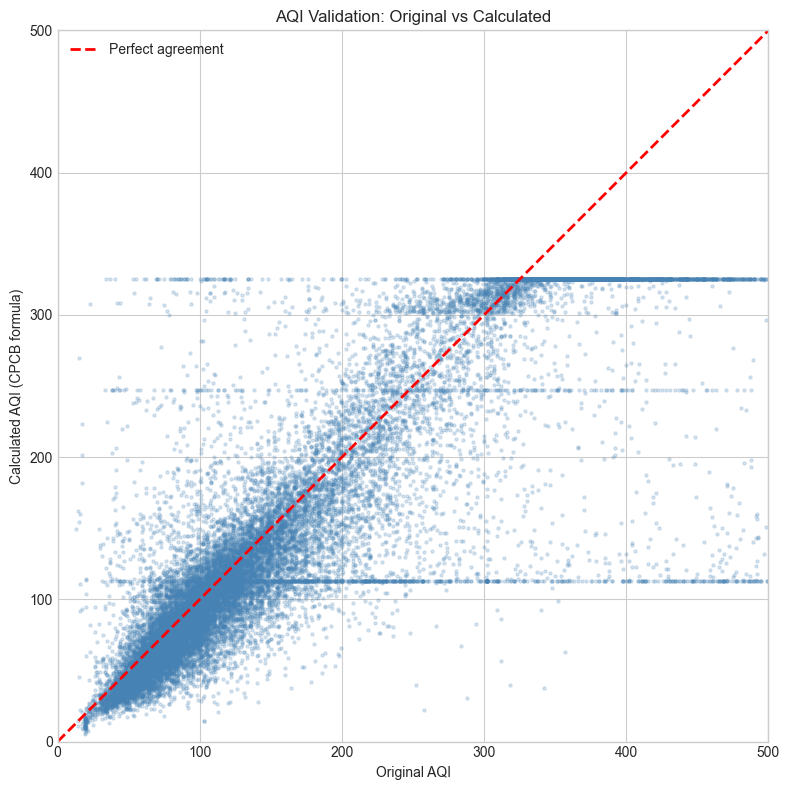

In [8]:
# Scatter: original vs calculated AQI
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison_df['AQI'], comparison_df['AQI_Calculated'], alpha=0.2, s=5, color='steelblue')
ax.plot([0, 500], [0, 500], 'r--', linewidth=2, label='Perfect agreement')
ax.set_xlabel('Original AQI')
ax.set_ylabel('Calculated AQI (CPCB formula)')
ax.set_title('AQI Validation: Original vs Calculated')
ax.legend()
ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_aqi_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Cleaned Data (before feature engineering)

In [9]:
# Save the cleaned dataset
clean_cols = ['City', 'Date'] + pollutant_cols + ['AQI', 'AQI_Bucket']
df_clean = df[clean_cols].copy()

df_clean.to_parquet(DATA_PROCESSED / 'city_day_clean.parquet', index=False)
print(f"Saved cleaned data: {df_clean.shape}")
print(f"Remaining missing values:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

Saved cleaned data: (24850, 16)
Remaining missing values:
Series([], dtype: int64)


## 8. Feature Engineering

In [10]:
df_features = build_feature_matrix(df_clean)

print(f"\nFeature matrix shape: {df_features.shape}")
print(f"\nFeature categories:")
temporal = [c for c in df_features.columns if c in ['year','month','day_of_week','day_of_year','quarter','is_weekend','season']]
lag = [c for c in df_features.columns if 'lag_' in c]
rolling = [c for c in df_features.columns if 'rolling_' in c]
ratio = [c for c in df_features.columns if 'ratio' in c.lower()]
print(f"  Temporal features: {len(temporal)}")
print(f"  Lag features: {len(lag)}")
print(f"  Rolling features: {len(rolling)}")
print(f"  Ratio features: {len(ratio)}")
print(f"  Total features: {df_features.shape[1]}")

Adding temporal features...
Adding lag features...
Adding rolling features...


Adding pollutant ratios...
Encoding city...
Dropped 780 rows due to insufficient lag history
Final feature matrix: (24070, 146)

Feature matrix shape: (24070, 146)

Feature categories:
  Temporal features: 7
  Lag features: 72
  Rolling features: 48
  Ratio features: 2
  Total features: 146


## 9. Temporal Train/Val/Test Split

In [11]:
# Temporal split - NO random shuffle
df_features = df_features.sort_values('Date').reset_index(drop=True)
n = len(df_features)

train_end = int(n * (1 - TEST_SIZE - VAL_SIZE))
val_end = int(n * (1 - TEST_SIZE))

df_train = df_features.iloc[:train_end]
df_val = df_features.iloc[train_end:val_end]
df_test = df_features.iloc[val_end:]

print(f"Train: {len(df_train)} rows ({len(df_train)/n*100:.1f}%)")
print(f"  Date range: {df_train['Date'].min().date()} to {df_train['Date'].max().date()}")
print(f"Val:   {len(df_val)} rows ({len(df_val)/n*100:.1f}%)")
print(f"  Date range: {df_val['Date'].min().date()} to {df_val['Date'].max().date()}")
print(f"Test:  {len(df_test)} rows ({len(df_test)/n*100:.1f}%)")
print(f"  Date range: {df_test['Date'].min().date()} to {df_test['Date'].max().date()}")

# Verify temporal ordering (boundary dates can overlap since multiple cities share dates)
assert df_train['Date'].max() <= df_val['Date'].min(), "LEAKAGE: train dates after val start!"
assert df_val['Date'].max() <= df_test['Date'].min(), "LEAKAGE: val dates after test start!"
print("\nTemporal ordering verified - no data leakage.")

# Check per-city temporal integrity
leakage_found = False
for city in df_features['City'].unique():
    city_train = df_train[df_train['City'] == city]['Date'].max()
    city_val = df_val[df_val['City'] == city]['Date'].min()
    if pd.notna(city_train) and pd.notna(city_val):
        if city_train > city_val:
            print(f"  WARNING: {city} has train/val date overlap")
            leakage_found = True
if not leakage_found:
    print("Per-city temporal integrity: OK")

Train: 16849 rows (70.0%)
  Date range: 2015-01-31 to 2019-08-11
Val:   3610 rows (15.0%)
  Date range: 2019-08-11 to 2020-02-02
Test:  3611 rows (15.0%)
  Date range: 2020-02-02 to 2020-07-01

Temporal ordering verified - no data leakage.
Per-city temporal integrity: OK


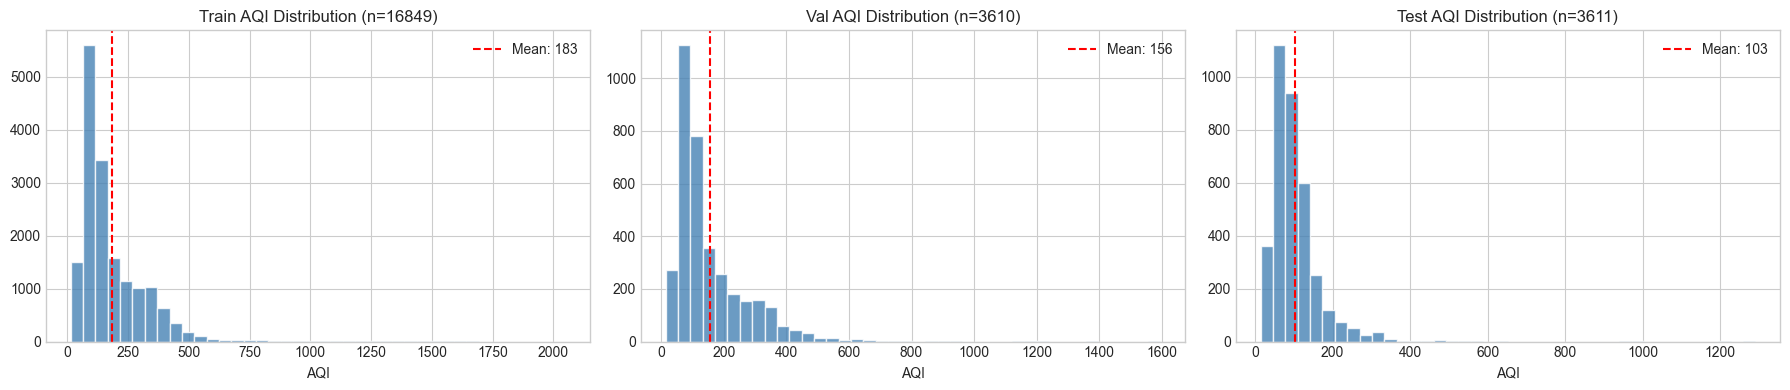

In [12]:
# AQI distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, split, name in zip(axes, [df_train, df_val, df_test], ['Train', 'Val', 'Test']):
    ax.hist(split['AQI'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name} AQI Distribution (n={len(split)})')
    ax.set_xlabel('AQI')
    ax.axvline(split['AQI'].mean(), color='red', linestyle='--',
               label=f'Mean: {split["AQI"].mean():.0f}')
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_split_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Processed Datasets

In [13]:
# Save full feature matrix
df_features.to_parquet(DATA_PROCESSED / 'features_full.parquet', index=False)

# Save splits
df_train.to_parquet(DATA_PROCESSED / 'train.parquet', index=False)
df_val.to_parquet(DATA_PROCESSED / 'val.parquet', index=False)
df_test.to_parquet(DATA_PROCESSED / 'test.parquet', index=False)

print("Saved to data/processed/:")
print(f"  features_full.parquet: {df_features.shape}")
print(f"  train.parquet: {df_train.shape}")
print(f"  val.parquet: {df_val.shape}")
print(f"  test.parquet: {df_test.shape}")

# Print feature list for reference
print(f"\nAll {df_features.shape[1]} columns:")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:3d}. {col}")

Saved to data/processed/:
  features_full.parquet: (24070, 146)
  train.parquet: (16849, 146)
  val.parquet: (3610, 146)
  test.parquet: (3611, 146)

All 146 columns:
    1. City
    2. Date
    3. PM2.5
    4. PM10
    5. NO
    6. NO2
    7. NOx
    8. NH3
    9. CO
   10. SO2
   11. O3
   12. Benzene
   13. Toluene
   14. Xylene
   15. AQI
   16. AQI_Bucket
   17. year
   18. month
   19. day_of_week
   20. day_of_year
   21. quarter
   22. is_weekend
   23. season
   24. PM2.5_lag_1
   25. PM2.5_lag_2
   26. PM2.5_lag_3
   27. PM2.5_lag_7
   28. PM2.5_lag_14
   29. PM2.5_lag_30
   30. PM10_lag_1
   31. PM10_lag_2
   32. PM10_lag_3
   33. PM10_lag_7
   34. PM10_lag_14
   35. PM10_lag_30
   36. NO_lag_1
   37. NO_lag_2
   38. NO_lag_3
   39. NO_lag_7
   40. NO_lag_14
   41. NO_lag_30
   42. NO2_lag_1
   43. NO2_lag_2
   44. NO2_lag_3
   45. NO2_lag_7
   46. NO2_lag_14
   47. NO2_lag_30
   48. NOx_lag_1
   49. NOx_lag_2
   50. NOx_lag_3
   51. NOx_lag_7
   52. NOx_lag_14
   53. NOx_la

## Summary

### Preprocessing Pipeline Applied:
1. **Linear interpolation** (gap <= 3 within city groups) - filled ~15-25% of missing values
2. **KNN imputation** (k=5, distance-weighted) - filled remaining using correlated pollutants
3. **Sparse row removal** - dropped rows with >50% missing pollutants
4. **Winsorization** - capped outliers at 1.5x IQR (preserved data, just capped extremes)
5. **AQI validation** - verified dataset AQI against CPCB formula

### Features Engineered:
- Temporal: year, month, day_of_week, quarter, is_weekend, season
- Lag features: 1,2,3,7,14,30-day lags for each pollutant
- Rolling stats: 3,7,14,30-day mean and std for key pollutants
- Ratios: PM2.5/PM10, NO2/NO
- City encoding: label-encoded

### Data Split:
- Temporal split (chronological, NO random shuffle)
- Train 70% / Val 15% / Test 15%
- No temporal leakage verified

### Next: Notebook 04 - Regression Models